In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [5]:
import os

print(os.listdir("/content"))

['.config', 'archive (3).zip', 'sample_data']


In [6]:
import zipfile

zip_path = "/content/archive (3).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("✅ Dataset Extracted Successfully!")

✅ Dataset Extracted Successfully!


In [7]:
import os

print(os.listdir("/content"))

['.config', 'archive (3).zip', 'Training', 'Testing', 'sample_data']


In [8]:
train_path = "/content/Training"
test_path = "/content/Testing"

print("Training Classes:")
print(os.listdir(train_path))

print("\nTesting Classes:")
print(os.listdir(test_path))

Training Classes:
['notumor', 'pituitary', 'meningioma', 'glioma']

Testing Classes:
['notumor', 'pituitary', 'meningioma', 'glioma']


In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import (
    EfficientNetB0,
    preprocess_input
)
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [10]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=20,
    width_shift_range=0.20,
    height_shift_range=0.20,
    zoom_range=0.20,
    shear_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


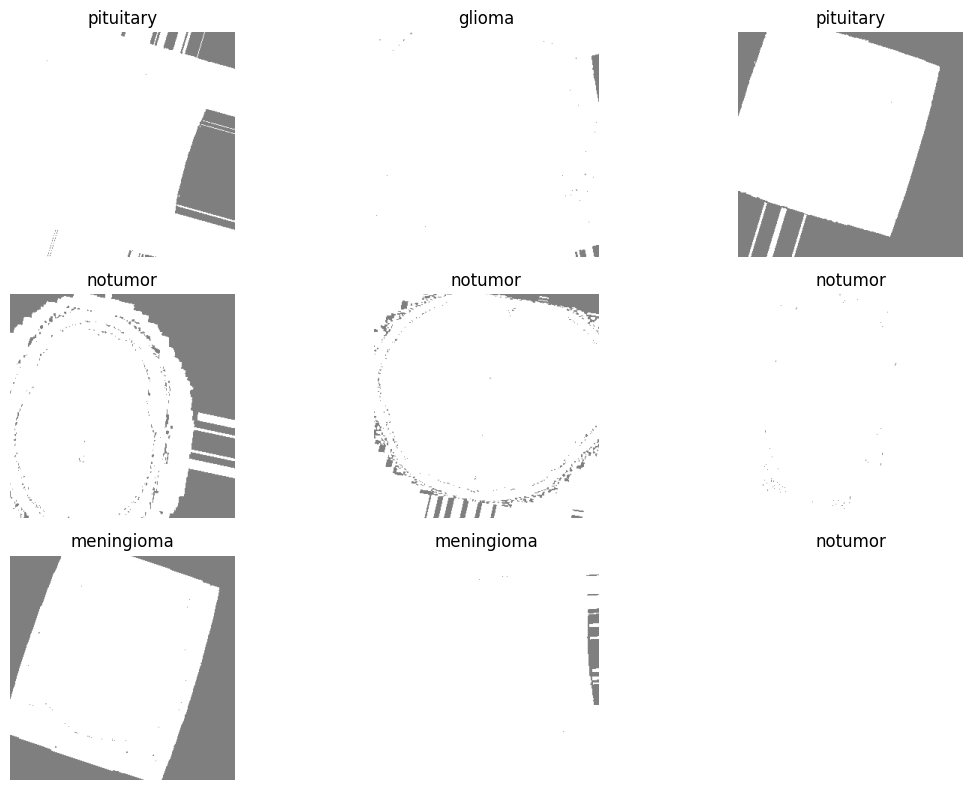

In [11]:
images, labels = next(train_generator)

class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow((images[i] + 1) / 2)   # Display correctly after preprocess_input
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(300, 300, 3)
)

# Fine-tune only the last 30 layers
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(4, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        512 │ block1a_se_excit

 Total params: 4,837,799 (18.45 MB)

 Trainable params: 2,284,388 (8.71 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

In [13]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model Compiled Successfully!")

✅ Model Compiled Successfully!


In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_brain_tumor_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("✅ Callbacks Created Successfully!")

✅ Callbacks Created Successfully!


In [15]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.5994 - loss: 0.9750
Epoch 1: val_accuracy improved from None to 0.81000, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 205s 939ms/step - accuracy: 0.7293 - loss: 0.7043 - val_accuracy: 0.8100 - val_loss: 0.5400 - learning_rate: 1.0000e-04
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.8685 - loss: 0.3682
Epoch 2: val_accuracy improved from 0.81000 to 0.85250, saving model to best_brain_tumor_model.keras

Epoch 2: finished saving model to best_brain_tumor_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 146s 830ms/step - accuracy: 0.8725 - loss: 0.3448 - val_accuracy: 0.8525 - val_loss: 0.4782 - learning_rate: 1.0000e-04
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.9000 - loss: 0.2724
Epoch 3: val_accuracy improved from 0.85250 to 0.86437, saving model to best_brain_tumor_model.keras

Epoch 3: 

In [16]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy * 100)

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.9300 - loss: 0.2852
Test Loss: 0.28516343235969543
Test Accuracy: 93.00000071525574


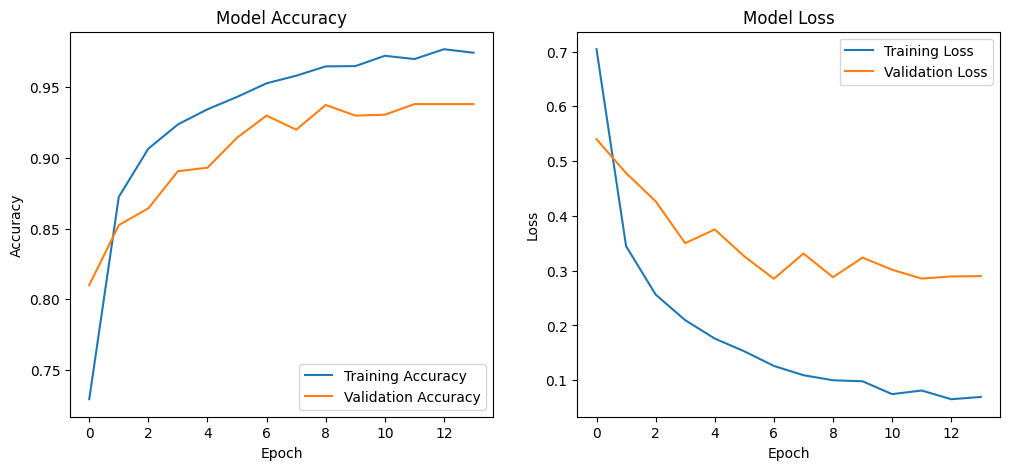

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step


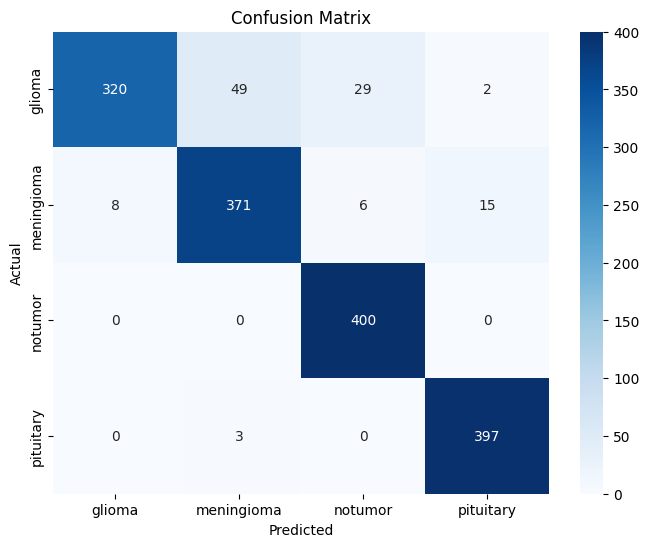

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(train_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.88      0.93      0.90       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



In [20]:
model.save("Brain_Tumor_Classification_Model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [21]:
from google.colab import files
files.download("Brain_Tumor_Classification_Model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>